# 🍷 Wine Quality Prediction
### Support Vector Machine (SVM) — Red Wine Quality Dataset

Importing libaries

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Importing Dataset

In [90]:
dataset = pd.read_csv("winequality-red.csv")
dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Target Transformation

In [91]:
dataset["quality"] = (dataset["quality"] > 5).astype(int)
print(dataset["quality"].value_counts())

quality
1    855
0    744
Name: count, dtype: int64


Feature Selection

In [92]:
correlation = dataset.corr()["quality"].sort_values(ascending=False)
print(correlation)

features= ["alcohol", "sulphates", "citric acid", "fixed acidity", "residual sugar", "pH", "free sulfur dioxide", "chlorides", "density", "total sulfur dioxide", "volatile acidity"]
target = "quality"

x = dataset[features]
y = dataset[target]

quality                 1.000000
alcohol                 0.434751
sulphates               0.218072
citric acid             0.159129
fixed acidity           0.095093
residual sugar         -0.002160
pH                     -0.003264
free sulfur dioxide    -0.061757
chlorides              -0.109494
density                -0.159110
total sulfur dioxide   -0.231963
volatile acidity       -0.321441
Name: quality, dtype: float64


Spliting Dataset into Training set and Test set

In [93]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Feature Scaling

In [94]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Training SVM Model

In [95]:
from sklearn.svm import SVC
model = SVC(kernel="rbf", C=1.0, gamma="scale")
model.fit(x_train, y_train)

print("Model trained succesfully!.")

Model trained succesfully!.


Model Evaluation

In [96]:
from sklearn.metrics import accuracy_score, recall_score, precision_score
y_pred = model.predict(x_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")

Accuracy: 0.77
Precision: 0.81
Recall: 0.77


Confusion Matrix

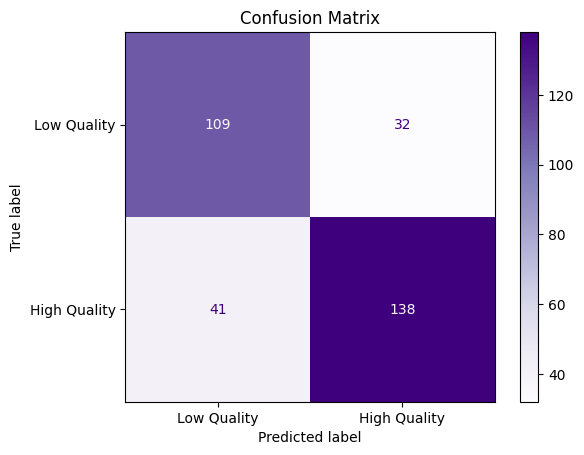

In [97]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low Quality", "High Quality"])
disp.plot(cmap="Purples")
plt.title("Confusion Matrix")
plt.show()

Kernel Comparison

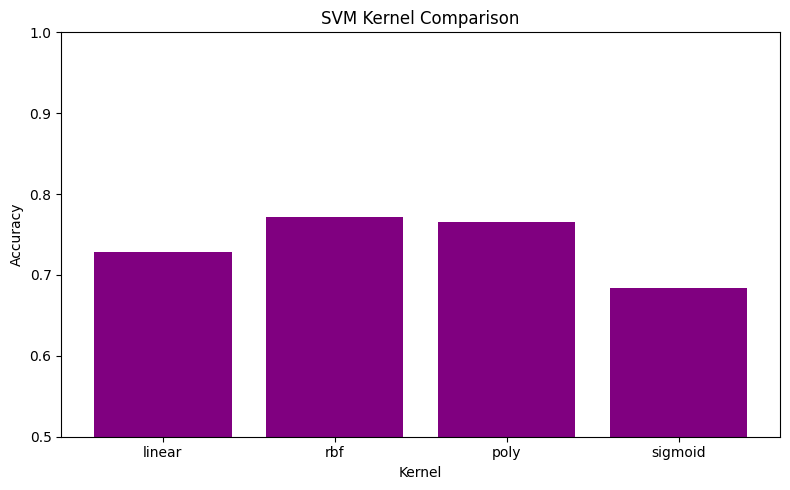

In [98]:
kernels = ["linear", "rbf", "poly", "sigmoid"]
accuracies = []

for kernel in kernels:
    m = SVC(kernel=kernel, C=1.0, gamma="scale")
    m.fit(x_train, y_train)
    pred = m.predict(x_test)
    accuracies.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8, 5))
plt.bar(kernels, accuracies, color="purple")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.title("SVM Kernel Comparison")
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()